# Hard Fair MCA, Soft Fair MCA, and PCA on Indicator Matrix

This notebook implements fairness-aware MCA variants and a PCA baseline on the German Credit dataset:
- **Classical MCA**
- **Hard Fair MCA**: projection onto the orthogonal complement of sensitive directions
- **Soft Fair MCA**: penalized eigendecomposition
- **Indicator PCA**: PCA directly on the one-hot indicator matrix

Sensitive attribute: **gender**.

In [2]:
import subprocess
import sys
from pathlib import Path


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA

project_root = Path.cwd()
local_pkg = project_root / "fair_unsupervised_fairness"
metrics_src = local_pkg / "src"
if metrics_src.exists() and str(metrics_src) not in sys.path:
    sys.path.insert(0, str(metrics_src))

try:
    from fair_repr_eval.metrics import (
        adversarial_leakage_score,
        groupwise_mmd,
        percentage_variance_retained,
    )
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", str(local_pkg)])
    from fair_repr_eval.metrics import (
        adversarial_leakage_score,
        groupwise_mmd,
        percentage_variance_retained,
    )

sns.set_theme(style="whitegrid")

## 1) Load Adult Dataset and Build Gender Variable

In [3]:
# Adult Income on OpenML
try:
    data = fetch_openml(name="adult", version=2, as_frame=True)
except Exception:
    data = fetch_openml(name="adult", version=1, as_frame=True)

X_raw = data.data.copy()
print("Shape X_raw:", X_raw.shape)
y = data.target.copy()

# Other studies have used a subset of the data to reduce computation time. We will do the same here.
# 5%, i.e. 2261 samples are generally used in the literature

N_sub = X_raw.shape[0] if X_raw.shape[0] <= 5000 else 2000
X_raw = X_raw.sample(n=N_sub, random_state=28).reset_index(drop=True)



g = X_raw["sex"].astype(str).str.lower().str.contains("female").astype(float).values


print("Shape X_raw:", X_raw.shape)

print("Female groups:", g.mean())

/opt/homebrew/anaconda3/lib/python3.11/site-packages/sklearn/datasets/_openml.py:968: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


Shape X_raw: (48842, 14)
Shape X_raw: (2000, 14)
Female groups: 0.3295


## 2) Build Indicator Matrix for MCA

In [4]:
# Keep categorical variables for MCA on complete disjunctive table
cat_cols = X_raw.select_dtypes(include=["object", "category"]).columns.tolist()
X_cat = X_raw[cat_cols].astype(str).replace("?", "missing").fillna("missing")
X_disj = pd.get_dummies(X_cat, prefix_sep="=", dtype=float)

N = X_disj.values  # n x m indicator matrix
n, m = N.shape

print("Categorical cols:", len(cat_cols))
print("Disjunctive table shape (n, m):", N.shape)

Categorical cols: 8
Disjunctive table shape (n, m): (2000, 96)


## 3) MCA Utilities + Fairness Utilities

In [5]:
import importlib
import methods

importlib.reload(methods)
from methods import ClassicMCA, IndicatorPCA, HardFairMCA, SoftFairMCA, FairPCA, FPCA, FPCAviaEigOpt

def make_Z_column_space(N, g_binary, eps=1e-12):
    # G_ind is n x 2 (male, female)
    G_ind = np.column_stack([1.0 - g_binary, g_binary])

    # Map individual sensitive info into column/modalities space: m x 2
    Z = N.T @ G_ind

    # Row-wise normalize to reduce pure frequency scale effects
    Z = Z / np.maximum(Z.sum(axis=1, keepdims=True), eps)
    return Z
def safe_corr(x, y, eps=1e-12):
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()
    x = x - x.mean()
    y = y - y.mean()
    den = np.sqrt((x @ x) * (y @ y))
    if den < eps:
        return 0.0
    return float((x @ y) / den)


def component_gender_corr(F, g):
    return np.array([safe_corr(F[:, j], g) for j in range(F.shape[1])])

def component_mean_abs_corr(F, G_ind):
    # Returns mean absolute corr across all sensitive groups for each component
    out = []
    for j in range(F.shape[1]):
        vals = [abs(safe_corr(F[:, j], G_ind[:, t])) for t in range(G_ind.shape[1])]
        out.append(np.mean(vals) if vals else 0.0)
    return np.asarray(out)

## 4) Run Classical, Hard Fair, and Soft Fair MCA

In [9]:
k = 10
lambda_fair = 0.001
import time

Z = make_Z_column_space(N, g)
Z_stack = np.column_stack([1.0 - g, g])

timings = {}

start_time = time.time()
res_classic = ClassicMCA(N, k=k).fit()
timings["classic"] = time.time() - start_time

start_time = time.time()
res_hard = HardFairMCA(N, Z=Z, k=k).fit()
timings["hard"] = time.time() - start_time

start_time = time.time()
res_soft = SoftFairMCA(N, Z=Z, k=k, lambda_fair=lambda_fair).fit()
timings["soft"] = time.time() - start_time

start_time = time.time()
res_pca = IndicatorPCA(N, k=k).fit()
timings["pca"] = time.time() - start_time

start_time = time.time()
res_fpca = FairPCA(N, Z=Z, k=k).fit()
timings["fair_pca"] = time.time() - start_time

start_time = time.time()
res_fPCA = FPCA(N, Z=Z_stack, k=k).fit()
timings["fPCA"] = time.time() - start_time

start_time = time.time()
res_fPCA_eigopt = FPCAviaEigOpt(N, Z=Z_stack, k=k).fit()
timings["fPCA_eigopt"] = time.time() - start_time

method_embeddings = {
    "classic": res_classic.F,
    "hard": res_hard.F,
    "soft": res_soft.F,
    "pca": res_pca.F,
    "fair_pca": res_fpca.F,
    "fPCA": res_fPCA.F,
    "fPCA_eigopt": res_fPCA_eigopt.F,
}

metric_rows = []
for method, emb in method_embeddings.items():
    mmd = groupwise_mmd(emb, g)
    adv = adversarial_leakage_score(emb, g)
    metric_rows.append({
        "method": method,
        "rho_mean": np.mean(np.abs(component_gender_corr(emb, g))),
        "variance_retained_percent": percentage_variance_retained(N, emb),
        "mmd_mean": mmd["mean"],
        "deltaAccuracy": np.abs(adv["accuracy_mean"] - adv["majority_class_baseline"]),
        "running": timings[method],
    })

fair_metrics = pd.DataFrame(metric_rows).sort_values("method").reset_index(drop=True)

fair_metrics

FPCA fit completed for m_used=10.
Projection matrix shape: (96, 96)


,method,rho_mean,variance_retained_percent,mmd_mean,deltaAccuracy,running
0,classic,0.188482,19.181830,0.186840,0.2955,0.109856
1,fPCA,0.286038,19.427541,0.313132,0.3295,17.356128
2,fPCA_eigopt,0.272379,16.049166,0.283338,0.2890,0.022657
3,fair_pca,0.095098,16.458429,0.020284,0.0540,0.071766
4,hard,0.069695,16.091922,0.040444,0.0230,0.490555
5,pca,0.213096,18.995739,0.139688,0.3295,0.024227
6,soft,0.069824,16.151813,0.042514,0.0305,5.087729


In [6]:
lambda_fair = 0.001
metric_rows = []

Z = make_Z_column_space(N, g)

Z_stack = np.column_stack([1.0 - g, g])  #

for k in range(1, 11):

    res_soft = SoftFairMCA(N, Z=Z, k=k, lambda_fair=lambda_fair).fit()
    emb = res_soft.F

    mmd = groupwise_mmd(emb, g)
    adv = adversarial_leakage_score(emb, g)
    metric_rows.append({
        "components": k,
        "rho_mean": np.mean(np.abs(component_gender_corr(emb, g))),
        "variance_retained_percent": percentage_variance_retained(N, emb),
        "mmd_mean": mmd["mean"],
        "deltaAccuracy": np.abs(adv["accuracy_mean"] - adv["majority_class_baseline"]),
    })

fair_metrics = pd.DataFrame(metric_rows).sort_values("components").reset_index(drop=True)

fair_metrics

,components,rho_mean,variance_retained_percent,mmd_mean,deltaAccuracy
0,1,0.005390,2.188605,0.012494,0.0000
1,2,0.119099,4.645059,0.122415,0.0050
2,3,0.129146,6.724303,0.083648,0.0200
3,4,0.110704,8.272445,0.070114,0.0180
4,5,0.099263,9.853960,0.064549,0.0265
5,6,0.100967,11.328641,0.060286,0.0300
6,7,0.086754,12.503896,0.053459,0.0285
7,8,0.077910,13.779303,0.047630,0.0280
8,9,0.073688,14.971234,0.045773,0.0300
9,10,0.069824,16.151813,0.042514,0.0305


In [8]:
k = 10
metric_rows = []

lambda_grid = np.array([0.0, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1])


Z = make_Z_column_space(N, g)

Z_stack = np.column_stack([1.0 - g, g])  #

for lambda_fair in lambda_grid:

    res_soft = SoftFairMCA(N, Z=Z, k=k, lambda_fair=lambda_fair).fit()
    emb = res_soft.F

    mmd = groupwise_mmd(emb, g)
    adv = adversarial_leakage_score(emb, g)
    metric_rows.append({
        "lambda_fair": lambda_fair,
        "rho_mean": np.mean(np.abs(component_gender_corr(emb, g))),
        "variance_retained_percent": percentage_variance_retained(N, emb),
        "mmd_mean": mmd["mean"],
        "deltaAccuracy": np.abs(adv["accuracy_mean"] - adv["majority_class_baseline"]),
    })

fair_metrics = pd.DataFrame(metric_rows).sort_values("lambda_fair").reset_index(drop=True)

fair_metrics

,lambda_fair,rho_mean,variance_retained_percent,mmd_mean,deltaAccuracy
0,0.00000,0.188482,19.181830,0.187022,0.2955
1,0.00001,0.186488,18.883060,0.169156,0.2655
2,0.00005,0.149336,17.419491,0.097656,0.1525
3,0.00010,0.104335,16.743371,0.066782,0.1080
4,0.00050,0.070764,16.213076,0.044701,0.0365
5,0.00100,0.069824,16.151813,0.042514,0.0305
6,0.00500,0.069734,16.103785,0.040841,0.0245
7,0.01000,0.069715,16.097846,0.040645,0.0235
8,0.05000,0.069699,16.093106,0.040484,0.0230
9,0.10000,0.069697,16.092514,0.040464,0.0230


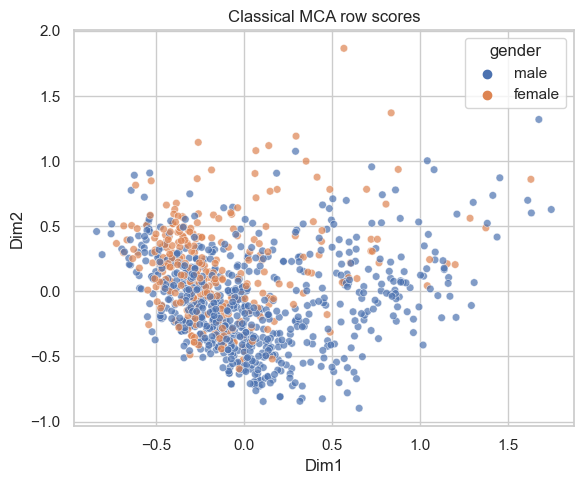

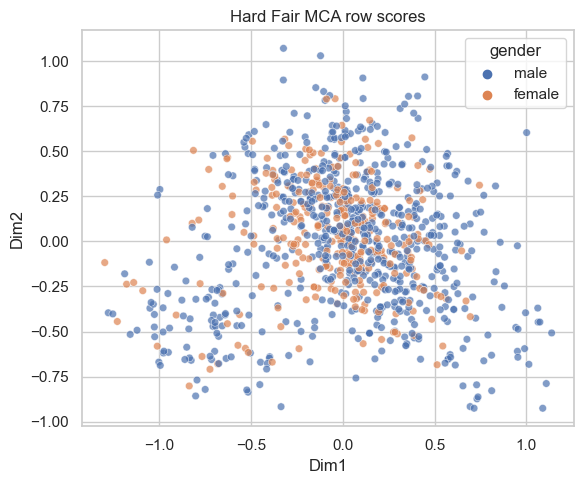

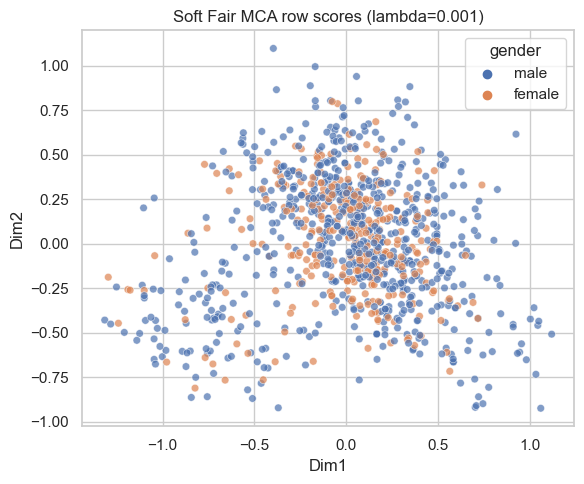

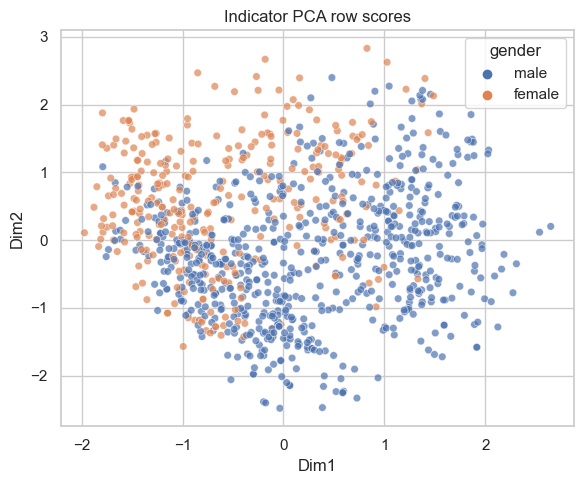

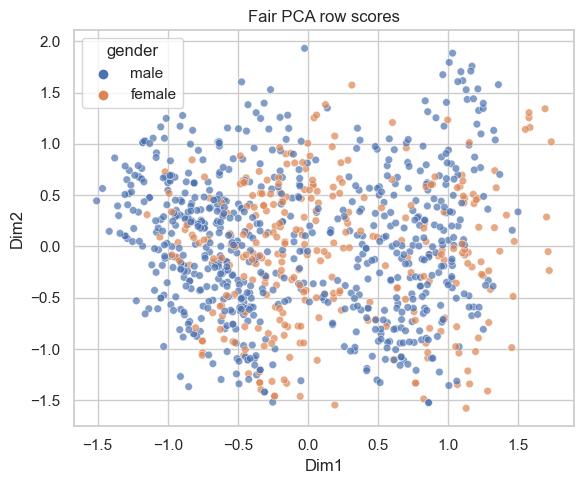

In [ ]:
def scatter_scores(F, labels, title):
    df = pd.DataFrame({
        "Dim1": F[:, 0],
        "Dim2": F[:, 1],
        "gender": labels
    })
    plt.figure(figsize=(6, 5))
    sns.scatterplot(data=df, x="Dim1", y="Dim2", hue="gender", alpha=0.7, s=30)
    plt.title(title)
    plt.tight_layout()
    plt.show()

scatter_scores(res_classic.F, gender, "Classical MCA row scores")
scatter_scores(res_hard.F, gender, "Hard Fair MCA row scores")
scatter_scores(res_soft.F, gender, f"Soft Fair MCA row scores (lambda={lambda_fair})")
scatter_scores(res_pca.F, gender, "Indicator PCA row scores")
scatter_scores(res_fpca.F, gender, "Fair PCA row scores")

## 5) Adversarial Study on Gender Leakage

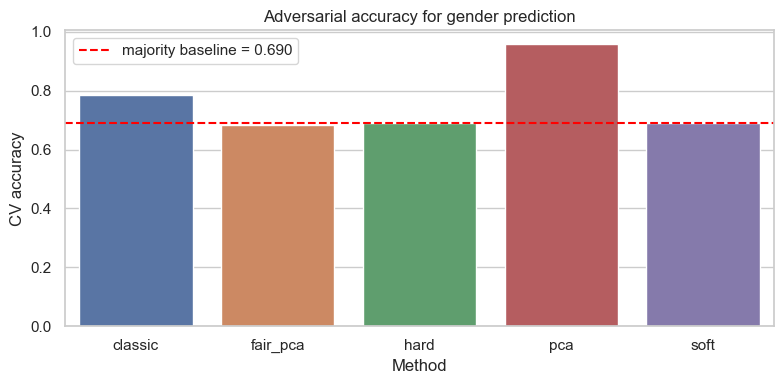

In [33]:
adv_df = fair_metrics[[
    "method",
    "adversarial_accuracy_mean",
    "adversarial_majority_class_baseline",
]].copy()
adv_df

plt.figure(figsize=(8, 4))
sns.barplot(data=adv_df, x="method", y="adversarial_accuracy_mean")
baseline = float(adv_df["adversarial_majority_class_baseline"].iloc[0])
plt.axhline(baseline, color="red", linestyle="--", label=f"majority baseline = {baseline:.3f}")
plt.title("Adversarial accuracy for gender prediction")
plt.ylabel("CV accuracy")
plt.xlabel("Method")
plt.legend()
plt.tight_layout()
plt.show()

## 6) Lambda_fair Sensitivity Study

In [34]:
lambda_grid = np.array([0.0, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1])
lambda_rows = []

for lam in lambda_grid:
    res_lam = soft_fair_mca(N, Z=Z, k=k, lambda_fair=float(lam))
    corr_lam = component_gender_corr(res_lam["F"], g)
    mmd_lam = groupwise_mmd(res_lam["F"], gender)
    adv_lam = adversarial_leakage_score(res_lam["F"], gender)
    lambda_rows.append({
        "lambda_fair": float(lam),
        "mean_abs_corr": float(np.mean(np.abs(corr_lam))) if len(corr_lam) else 0.0,
        "sum_explained_variance_ratio": float(np.sum(res_lam["explained_variance_ratio"])),
        "mmd_mean": mmd_lam["mean"],
        "adv_accuracy": adv_lam["accuracy_mean"],
    })

lambda_study = pd.DataFrame(lambda_rows)
lambda_study

,lambda_fair,mean_abs_corr,sum_explained_variance_ratio,mmd_mean,adv_accuracy
0,0.00000,0.229346,0.219637,0.095373,0.786
1,0.00001,0.230357,0.218978,0.089077,0.783
2,0.00005,0.210071,0.217241,0.065610,0.750
3,0.00010,0.162902,0.216680,0.043328,0.724
4,0.00050,0.033698,0.218205,0.007894,0.690
5,0.00100,0.035500,0.218201,0.006521,0.690
6,0.00500,0.053728,0.217250,0.008555,0.688
7,0.01000,0.056325,0.217119,0.009095,0.689
8,0.05000,0.058455,0.217012,0.009584,0.689
9,0.10000,0.058724,0.216999,0.009649,0.689


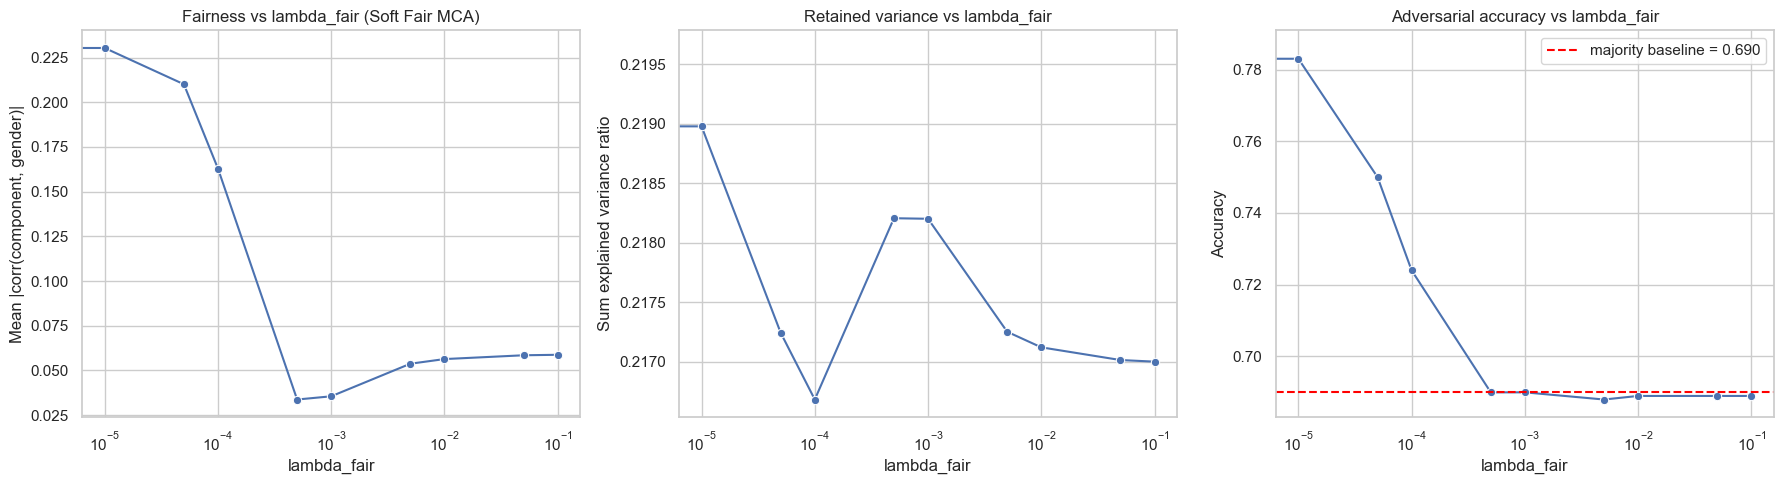

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
baseline = float(fair_metrics["adversarial_majority_class_baseline"].iloc[0])

sns.lineplot(data=lambda_study, x="lambda_fair", y="mean_abs_corr", marker="o", ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_title("Fairness vs lambda_fair (Soft Fair MCA)")
axes[0].set_ylabel("Mean |corr(component, gender)|")
axes[0].set_xlabel("lambda_fair")

sns.lineplot(data=lambda_study, x="lambda_fair", y="sum_explained_variance_ratio", marker="o", ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("Retained variance vs lambda_fair")
axes[1].set_ylabel("Sum explained variance ratio")
axes[1].set_xlabel("lambda_fair")

sns.lineplot(data=lambda_study, x="lambda_fair", y="adv_accuracy", marker="o", ax=axes[2])
axes[2].set_xscale("log")
axes[2].axhline(baseline, color="red", linestyle="--", label=f"majority baseline = {baseline:.3f}")
axes[2].set_title("Adversarial accuracy vs lambda_fair")
axes[2].set_ylabel("Accuracy")
axes[2].set_xlabel("lambda_fair")
axes[2].legend()

plt.tight_layout()
plt.show()

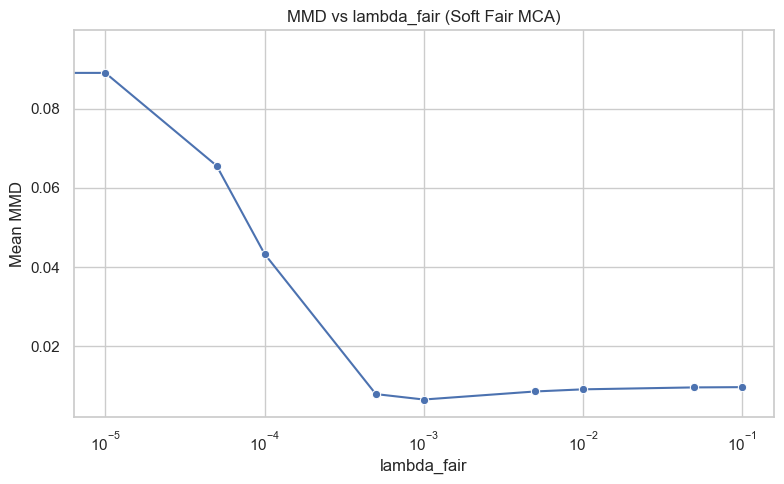

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(data=lambda_study, x="lambda_fair", y="mmd_mean", marker="o", ax=ax)
ax.set_xscale("log")
ax.set_title("MMD vs lambda_fair (Soft Fair MCA)")
ax.set_ylabel("Mean MMD")
ax.set_xlabel("lambda_fair")

plt.tight_layout()
plt.show()

## 7) Notes

- Hard Fair MCA tends to reduce component-gender correlation more aggressively, often with a stronger inertia loss.
- Soft Fair MCA controls the trade-off with $\\lambda$: larger values usually improve fairness but reduce explained structure.
- Indicator PCA is a useful baseline because it ignores the MCA chi-square geometry and fairness constraints.
- You can tune `lambda_fair` and `k` to explore this trade-off.